In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter1d

def weighted_moving_average(y, window=9, kind='gaussian', sigma=None):
    """
    Smooth 1D data using a weighted moving average.
    
    Parameters
    ----------
    y : array_like
        Input signal to smooth.
    window : int
        Window size (odd number recommended).
    kind : str
        'gaussian' or 'triangular' weighting scheme.
    sigma : float, optional
        Standard deviation for Gaussian weights (defaults to window/4).
    
    Returns
    -------
    y_smooth : ndarray
        Smoothed signal, same length as input.
    """
    y = np.asarray(y, dtype=float)
    if window % 2 == 0:
        window += 1  # force odd window for symmetry
    half = window // 2

    if kind == 'gaussian':
        if sigma is None:
            sigma = window / 4
        x = np.arange(-half, half + 1)
        weights = np.exp(-0.5 * (x / sigma) ** 2)
    elif kind == 'triangular':
        weights = 1 - np.abs(np.arange(-half, half + 1)) / (half + 1)
    else:
        raise ValueError("kind must be 'gaussian' or 'triangular'")

    weights /= weights.sum()

    # Pad edges via reflection to avoid boundary artifacts
    y_padded = np.pad(y, half, mode='reflect')
    y_smooth = np.convolve(y_padded, weights, mode='valid')

    return y_smooth

In [11]:
%matplotlib widget

In [ ]:
# Import and plot the raw spectra
data_path = Path(r'.')
fig_path = Path(r'./figures')

files = [
    '03_primo_Valence_He-I_2026-06-08__14h45m57s',
    '04_primo_Valence_He-I-killed_2026-06-08__14h51m52s',
    '05_primo_Valence_He-I_2026-06-08__14h56m06s',
    '07_primo_Valence_He-II-killed_2026-06-08__15h16m21s',
    '08_primo_Valence_He-II_2026-06-08__15h59m30s',
    '09_primo_Valence_He-I_2026-06-08__17h27m46s',
    '10_primo_Valence_He-I_2026-06-08__18h09m59s',
    '11_primo_Valence_He-I_2026-06-08__18h16m46s',
    '12_primo_Valence_He-I_2026-06-08__18h25m15s',
    '13_primo_backup_2026-06-08__18h37m19s'   
]

# Load all data
def load_xps(filepath):
    """Load a fixXPS-exported .txt file into a dict of arrays."""
    data = np.genfromtxt(filepath, names=True)
    return {name: data[name] for name in data.dtype.names}

spectra = []   # spectra[i] = {'file_name_1': dict, 'file_name_2': dict, ...}
for i in range(len(files)):
    spectra.append(load_xps(data_path / f'{files[i]}.txt'))
    # spectra[i]['counts_smoothed'] = weighted_moving_average(spectra[i]['counts'], kind='gaussian')
    # spectra[i]['counts_smoothed'] = gaussian_filter1d(spectra[i]['counts'], sigma=2)

In [ ]:
# Plot scatter of Kinetic Energy vs. counts for each file
fig_path.mkdir(parents=True, exist_ok=True)

for i in range(len(files)):
    s = spectra[i]
    fig, ax = plt.subplots()
    ax.scatter(s['KE_eV'], s['counts'], s=1)
    ax.set_xlabel('Kinetic Energy [eV]')
    ax.set_ylabel('counts [a.u.]')
    ax.set_title(files[i])
    fig.savefig(fig_path / f'{files[i]}.png', dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
# Plot scattter of smoothed counts vs kinetic energy for each file
for i in range(len(files)):
    s = spectra[i]
    fig, ax = plt.subplots()
    ax.scatter(s['KE_eV'], s['counts_smoothed'], s=1)
    ax.set_xlabel('Energia cinetica [eV]')
    ax.set_ylabel('Intensità [u.a.]')
    ax.set_title(f'{files[i]} smoothed')
    # fig.savefig(fig_path / f'{files[i]}.png', dpi=300, bbox_inches='tight')
    plt.show()

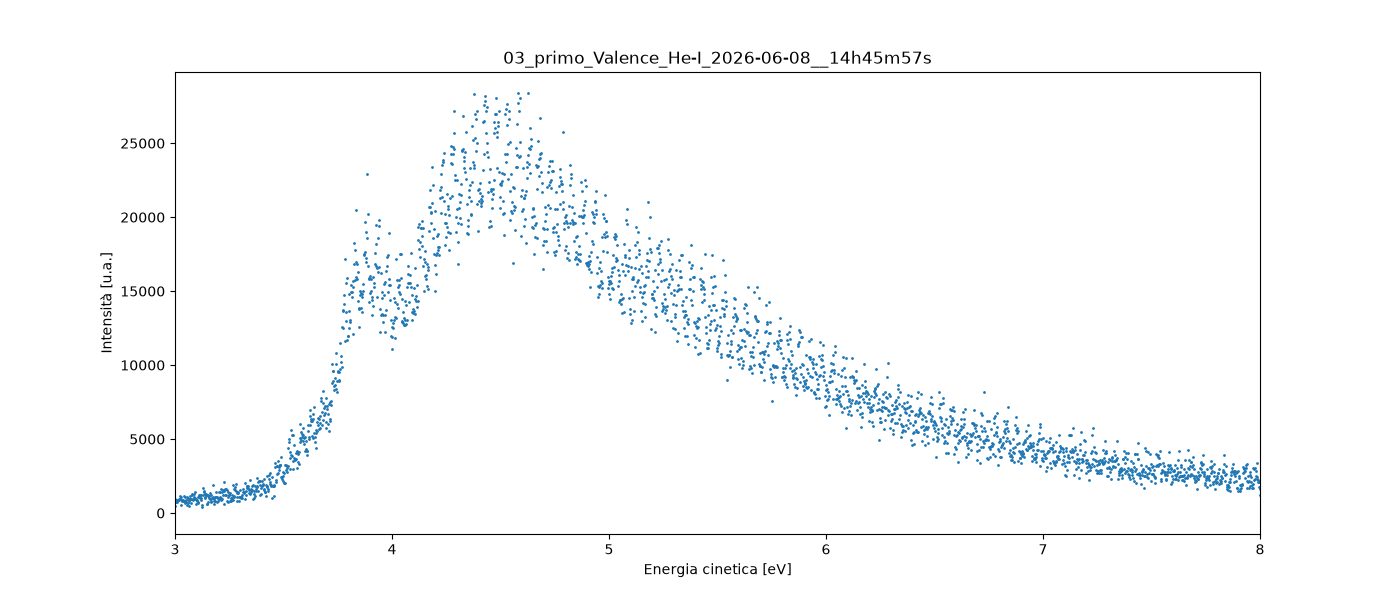

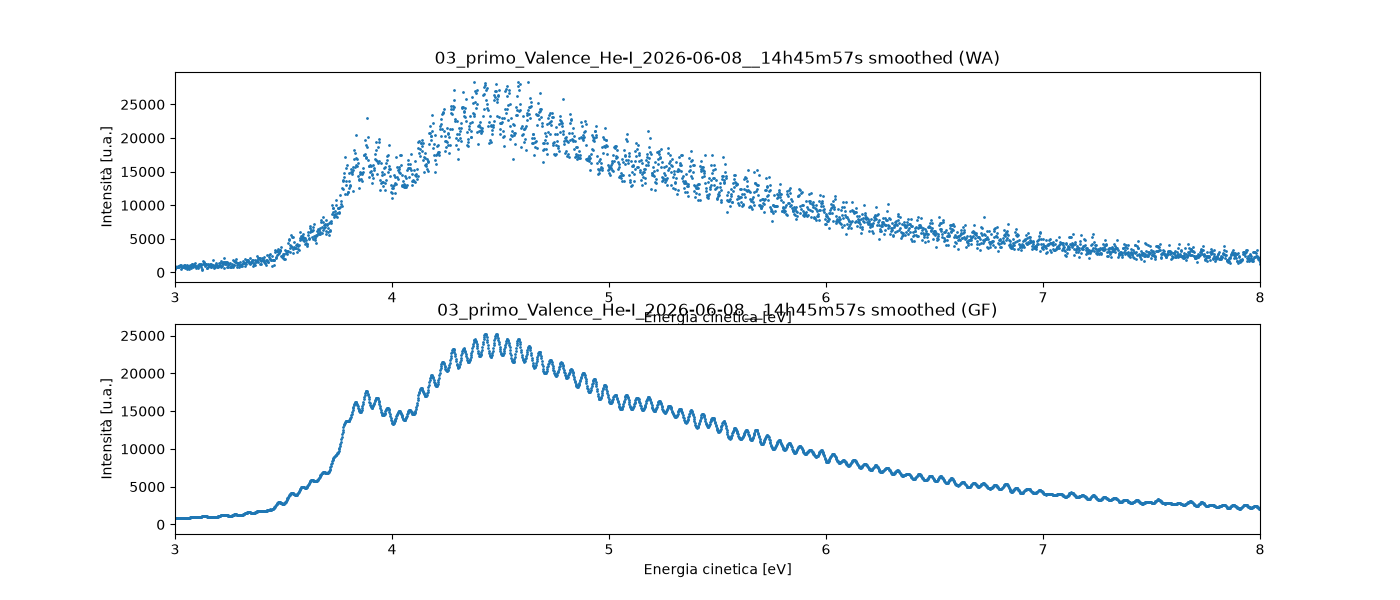

In [13]:
# Plot scatter of "03_primo_Valence_He-I_2026-06-08__14h45m57s"
s = spectra[0]
fig, ax = plt.subplots(figsize=(14, 6))
ax.scatter(s['KE_eV'], s['counts'], s=1)
ax.set_xlim(3, 8)
ax.set_xlabel('Energia cinetica [eV]')
ax.set_ylabel('Intensità [u.a.]')
ax.set_title(files[0])
# fig.savefig(fig_path / f'{files[0]}.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot smoothed spectra
window_size = 5
s['counts_smoothed'] = weighted_moving_average(s['counts'], window=window_size, kind='gaussian')

fig, ax = plt.subplots(2, 1, figsize=(14, 6))
ax[0].scatter(s['KE_eV'], s['counts'], s=1)
ax[0].set_xlim(3, 8)
ax[0].set_xlabel('Energia cinetica [eV]')
ax[0].set_ylabel('Intensità [u.a.]')
ax[0].set_title(rf'{files[0]} smoothed (WA)')

s['counts_smoothed'] = gaussian_filter1d(s['counts'], sigma=window_size)
ax[1].scatter(s['KE_eV'], s['counts_smoothed'], s=1)
ax[1].set_xlim(3, 8)
ax[1].set_xlabel('Energia cinetica [eV]')
ax[1].set_ylabel('Intensità [u.a.]')
ax[1].set_title(rf'{files[0]} smoothed (GF)')
plt.show()